In [1]:
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
json_files = glob.glob("results/*.json")

print(f"Found {len(json_files)} result files")

all_results = []

for path in json_files:
    with open(path, "r") as f:
        data = json.load(f)
        data["_source_file"] = path
        all_results.append(data)

Found 2 result files


In [7]:
rows = []

for exp in all_results:
    info = exp["experiment_info"]

    # Exact retraining
    if "exact_unlearning" in exp:
        rows.append({
            "method": "exact_retraining",
            "deleted_loss": exp["exact_unlearning"]["deleted_loss"],
            "retained_loss": None,
            "retained_accuracy": None,
            "deleted_confidence": None,
            "retained_confidence": None,
            "time_seconds": exp["exact_unlearning"]["time_seconds"]
        })

    # Gradient ascent
    if "approx_unlearning" in exp:
        m = exp["approx_unlearning"]["metrics"]
        rows.append({
            "method": "gradient_ascent",
            "deleted_loss": m["deleted_loss"],
            "retained_loss": m["retained_loss"],
            "retained_accuracy": None,
            "deleted_confidence": m.get("deleted_confidence"),
            "retained_confidence": m.get("retained_confidence"),
            "time_seconds": exp["approx_unlearning"]["time_seconds"]
        })

    # First-epoch reversal
    if "first_epoch_reversal" in exp:
        m = exp["first_epoch_reversal"]["metrics"]
        rows.append({
            "method": "first_epoch_reversal",
            "deleted_loss": m["deleted_loss"],
            "retained_loss": m["retained_loss"],
            "retained_accuracy": m.get("retained_accuracy"),
            "deleted_confidence": None,
            "retained_confidence": None,
            "time_seconds": exp["first_epoch_reversal"]["time_seconds"]
        })

In [8]:
df = pd.DataFrame(rows)
df

,method,deleted_loss,retained_loss,retained_accuracy,deleted_confidence,retained_confidence,time_seconds
0,exact_retraining,0.056612,NaN,NaN,NaN,NaN,65.097368
1,gradient_ascent,0.096872,0.079421,NaN,0.961179,0.964694,2.115686
2,first_epoch_reversal,0.074487,0.028162,0.991263,NaN,NaN,37.283534


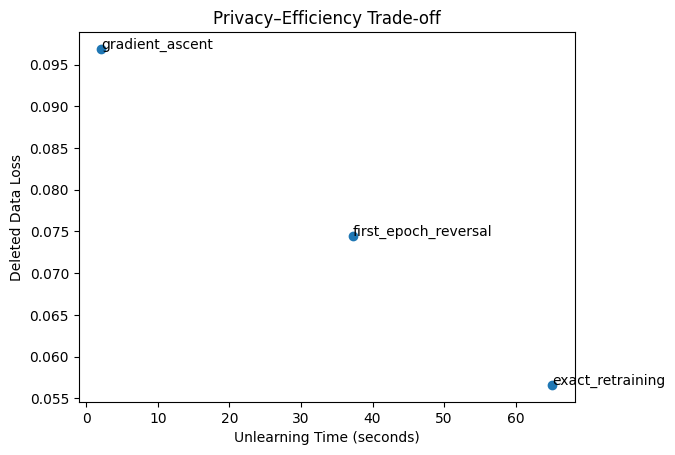

In [9]:
plt.figure()
plt.scatter(df["time_seconds"], df["deleted_loss"])

for i, method in enumerate(df["method"]):
    plt.annotate(method, (df["time_seconds"][i], df["deleted_loss"][i]))

plt.xlabel("Unlearning Time (seconds)")
plt.ylabel("Deleted Data Loss")
plt.title("Privacy–Efficiency Trade-off")
plt.show()

In [10]:
df[["method", "retained_loss", "retained_accuracy"]]

,method,retained_loss,retained_accuracy
0,exact_retraining,NaN,NaN
1,gradient_ascent,0.079421,NaN
2,first_epoch_reversal,0.028162,0.991263


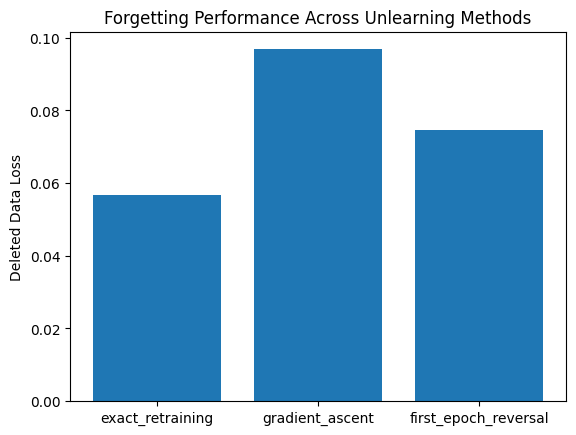

In [11]:
df_plot = df.dropna(subset=["deleted_loss"])

plt.figure()
plt.bar(df_plot["method"], df_plot["deleted_loss"])
plt.ylabel("Deleted Data Loss")
plt.title("Forgetting Performance Across Unlearning Methods")
plt.show()

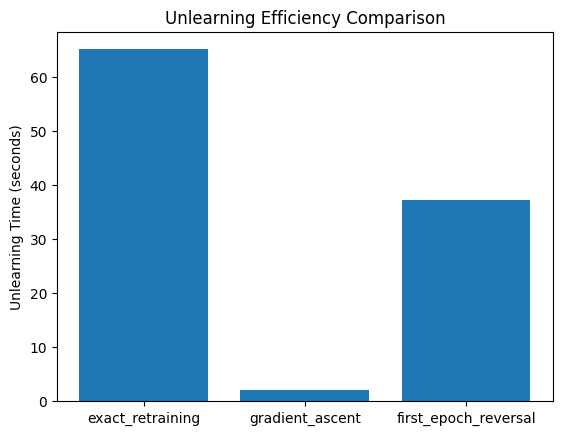

In [12]:
plt.figure()
plt.bar(df_plot["method"], df_plot["time_seconds"])
plt.ylabel("Unlearning Time (seconds)")
plt.title("Unlearning Efficiency Comparison")
plt.show()

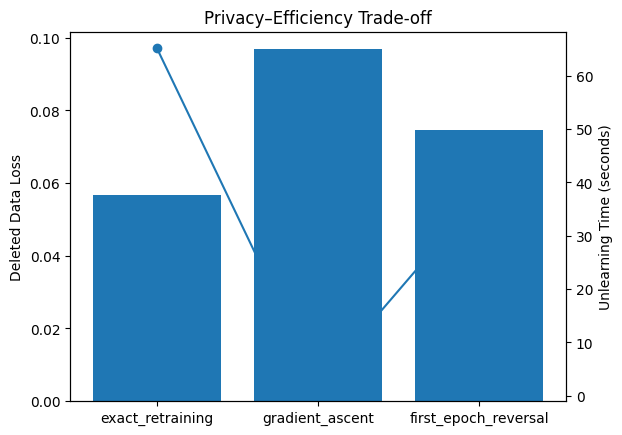

In [13]:
fig, ax1 = plt.subplots()

ax1.bar(df["method"], df["deleted_loss"])
ax1.set_ylabel("Deleted Data Loss")

ax2 = ax1.twinx()
ax2.plot(df["method"], df["time_seconds"], marker="o")
ax2.set_ylabel("Unlearning Time (seconds)")

plt.title("Privacy–Efficiency Trade-off")
plt.show()

In [14]:
df_ranked = df.sort_values("deleted_loss", ascending=False)
df_ranked[["method", "deleted_loss", "time_seconds"]]

,method,deleted_loss,time_seconds
1,gradient_ascent,0.096872,2.115686
2,first_epoch_reversal,0.074487,37.283534
0,exact_retraining,0.056612,65.097368
